# Clasificación de peticiones HTTP maliciosas con un Perceptrón Multicapa

**Tarea Académica 1**

Este trabajo implementa una red neuronal para clasificar **peticiones a un servidor web** —líneas de un `access.log` de nginx— en seis categorías de comportamiento. El dataset procede de un servidor propio expuesto a internet, del que se capturaron **1 386 105 peticiones** entre el 16 y el 30 de agosto de 2026.

El *forward pass*, el *backpropagation* y el descenso de gradiente están implementados con operaciones matriciales de NumPy, sin usar librerías de redes neuronales para el entrenamiento.

La rúbrica de la TA1 evalúa cuatro criterios:

| Criterio | Puntos |
|---|---|
| **C1** · Arquitectura: capas, neuronas, dimensiones y activaciones | 5 |
| **C2** · Pesos y sesgos: método de inicialización justificado | 5 |
| **C3** · *Forward pass* con operaciones matriciales, verificado | 5 |
| **C4** · Backpropagation: gradientes, bucle con α, convergencia, comparación de tasas | 5 |
| **Total** | **20** |


## 1 · El dataset

Cada línea de un `access.log` de nginx registra una petición HTTP:

```
20.116.17.175 - - [16/Aug/2026:00:00:07 +0000] "GET /wtiiy.php HTTP/1.1" 404 162 "-" "-"
```

De cada línea se extraen: la IP de origen, la marca de tiempo, el método, la URL solicitada, el código de respuesta y el *user-agent*.

**Las seis clases.** No se etiquetan a mano: cada petición recibe su clase mediante una regla documentada que combina el texto de la URL con el comportamiento agregado de su IP a lo largo de los 15 días de captura.

| Clase | Regla de etiquetado |
|---|---|
| `visita_puntual` | IP con menos de 50 peticiones, tasa de 404 inferior al 5 %, respuestas 2xx/3xx |
| `automata_benigno` | IP con 50 o más peticiones, tasa de 404 inferior al 5 %, 5 o menos rutas distintas |
| `wp_bruteforce` | `POST` a `wp-login` desde una IP con 20 o más intentos del mismo tipo |
| `xmlrpc_abuse` | URL con `xmlrpc` desde una IP con 50 o más peticiones a ese endpoint |
| `webshell_scan` | Respuesta 404 desde una IP que probó 20 o más rutas inexistentes distintas |
| `secret_hunt` | URL que busca credenciales (`.env`, `.git`, `.aws`, `.sql`) desde una IP con 5 o más rutas 404 |

Las peticiones que no cumplen ninguna regla se descartan (aproximadamente un tercio del log), en lugar de asignarles una clase por defecto.

**Partición del conjunto.** Los datos se dividen **por día**, no aleatoriamente: entrenamiento del 16 al 26 de agosto, validación del 27 al 28, y prueba del 29 al 30. El modelo se evalúa así sobre tráfico posterior al que vio durante el entrenamiento, que es la situación real de despliegue. Antes de particionar se eliminan los pares (URL, *user-agent*) repetidos.


In [ ]:
#@title Load dataset and configuration { display-mode: "form" }
STUDENT_NAME = "Jose Nunez (B4rt)"  #@param {type:"string"}

import warnings, math, re, json, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter
warnings.filterwarnings('ignore')

SEED = 42
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True,
                     'grid.color': '#EAECEF', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titleweight': 'bold',
                     'legend.frameon': False})
print("Student:", STUDENT_NAME)

# Radio buttons plus free text to record each answer.
ANSWERS = {}
try:
    import ipywidgets as widgets
    from IPython.display import display

    def answer_box(criterion, options, default_text=''):
        radio = widgets.RadioButtons(options=options, value=None,
                                     layout=widgets.Layout(width='auto'))
        text = widgets.Textarea(value=default_text,
                                placeholder='Sustenta tu eleccion con la evidencia del '
                                'cuaderno (tablas y figuras de esta seccion).',
                                layout=widgets.Layout(width='95%', height='260px'))
        button = widgets.Button(description='Guardar respuesta', button_style='danger')
        out = widgets.Output()

        def save(_):
            out.clear_output()
            with out:
                if radio.value is None or not text.value.strip():
                    print("Elige una opcion y escribe tu sustento antes de guardar.")
                else:
                    ANSWERS[criterion] = (radio.value, text.value.strip())
                    print(f"{criterion} - opcion elegida: {radio.value}")
                    print(f"Sustento: {text.value.strip()}")

        button.on_click(save)
        display(widgets.VBox([widgets.HTML(
            f"<b style='color:#C0392B;font-size:1.05em'>RESPUESTA - {criterion}</b>"),
            radio, text, button, out],
            layout=widgets.Layout(border='3px solid #D64545', padding='12px')))
except ImportError:
    def answer_box(criterion, options, default_text=''):
        print(f"{criterion} - elige una opcion y sustenta en una celda nueva:")
        for o in options:
            print("  -", o)
        if default_text:
            print("\nSustento registrado:\n" + default_text)

# Balanced sample split by day, produced by extraer_dataset.py from the full
# access.log (1,386,105 requests, 16-30 August).
DATASET_PATH = 'trafico_honeypot.jsonl'
if not os.path.exists(DATASET_PATH):
    for candidate in ['/content/trafico_honeypot.jsonl', '../trafico_honeypot.jsonl']:
        if os.path.exists(candidate):
            DATASET_PATH = candidate
            break
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        "trafico_honeypot.jsonl not found. Generate it with:\n"
        "  python3 extraer_dataset.py --log /path/to/access_anon.log")

CLASSES = ["visita_puntual", "automata_benigno", "wp_bruteforce",
           "xmlrpc_abuse", "webshell_scan", "secret_hunt"]

# Field names are normalized to English on load, so the rest of the notebook
# uses a single naming scheme regardless of the key names in the file.
KEY_MAP = {'metodo': 'method', 'clase': 'label', 'particion': 'partition',
           'cadencia_cv': 'cadence_cv', 'n_posicion': 'n_position'}
log_rows = [{KEY_MAP.get(k, k): v for k, v in json.loads(l).items()}
            for l in open(DATASET_PATH, encoding='utf-8')]
urls = [r['url'] for r in log_rows]
user_agents = [r['ua'] for r in log_rows]
methods = [r['method'] for r in log_rows]
labels = [r['label'] for r in log_rows]
partition = [r['partition'] for r in log_rows]

# Per-request time features. They are computed in extraer_dataset.py because they
# need each IP's full history over the 1.39M-line log, not just the rows kept in
# this sample.
dt_prev = [r['dt_prev'] for r in log_rows]
burst60 = [r['burst60'] for r in log_rows]
cadence_cv = [r['cadence_cv'] for r in log_rows]
n_position = [r['n_position'] for r in log_rows]

print(f"\nRequests loaded: {len(log_rows)} - classes: {len(CLASSES)}")
print("Rows per class:", {c: labels.count(c) for c in CLASSES})
print("Rows per partition:", {p: partition.count(p) for p in ('train', 'val', 'test')})
print("\nSample rows (one line = one request):")
for i in range(6):
    print(f"  [{labels[i]:>16}] {methods[i]:<5} {urls[i][:70]}")

## 2 · Extracción de características y matriz de diseño

Una red neuronal opera sobre números, no sobre texto. Cada línea del log se convierte en un **vector de características** $\mathbf{x} \in \mathbb{R}^{d}$. Apilando los $N$ vectores, uno por fila, se obtiene la **matriz de diseño** $X \in \mathbb{R}^{N \times d}$.

El vector se compone de cuatro bloques, $d = 127$ en total:

| Bloque | Dim. | Contenido |
|---|---|---|
| 1 · Léxicas | 23 | longitud de la URL; conteo de `/ = % . - _ ? &`; entropía de Shannon; dígitos; mayúsculas; profundidad media de segmento; longitud, entropía y estructura del *user-agent*; método (`GET`/`POST`/otro) |
| 2 · Bigramas de URL | 70 | frecuencia de los 70 pares de caracteres más comunes en las URLs de entrenamiento |
| 3 · Bigramas de *user-agent* | 30 | ídem sobre el campo *user-agent* |
| 4 · Temporales | 4 | `dt_prev`, `burst60`, `cadence_cv`, `n_position` |

**Dos decisiones deliberadas sobre qué NO entra en el vector:**

- **La IP no es una variable.** Se usa únicamente para agrupar peticiones al calcular el bloque 4 y para escribir la etiqueta. Incluirla como característica permitiría al modelo memorizar atacantes concretos en lugar de aprender qué distingue a un ataque.
- **El código de respuesta tampoco.** La regla que define `webshell_scan` usa `status == 404`; si el código fuera además una característica, el modelo estaría leyendo su propia etiqueta.

El vocabulario de bigramas se cuenta **solo sobre el conjunto de entrenamiento**: contarlo sobre el dataset completo dejaría que el vocabulario incorpore información de las URLs de prueba.

Finalmente, cada columna se normaliza al rango $[0,1]$ usando el mínimo y máximo **del entrenamiento**, para que la sumatoria $z=\sum_i w_i x_i + b$ no quede dominada por las columnas de mayor escala.


In [71]:
#@title Build the design matrix X { display-mode: "form" }
def entropy(s):
    """Shannon entropy of a string."""
    if not s:
        return 0.0
    p = [s.count(c) / len(s) for c in set(s)]
    return -sum(x * math.log2(x) for x in p)


def lexical_features(url, ua, method):
    """Block 1: 23 numeric features from the URL, the user-agent and the method."""
    return [len(url), url.count('/'), url.count('='), url.count('%'), url.count('.'),
            url.count('-'), url.count('_'), url.count('?'), url.count('&'),
            round(entropy(url), 3), len(re.findall(r'\d', url)),
            len(re.findall(r'[A-Z]', url)), url.count('//'),
            round(len(url) / max(url.count('/'), 1), 2),
            len(ua), round(entropy(ua), 3), int(ua == '-'), ua.count(' '),
            ua.count('/'), ua.count('.'),
            int(method == 'POST'), int(method == 'GET'), int(method not in ('GET', 'POST'))]


LEXICAL_NAMES = ["url_len", "n_slash", "n_equal", "n_percent", "n_dot", "n_dash",
                 "n_underscore", "n_question", "n_ampersand", "url_entropy", "n_digits",
                 "n_upper", "n_double_slash", "mean_depth", "ua_len", "ua_entropy",
                 "ua_is_dash", "ua_n_spaces", "ua_n_slash", "ua_n_dot", "is_POST", "is_GET",
                 "other_method"]

# Split by day: already resolved in the .jsonl file.
i_tr = [i for i, p in enumerate(partition) if p == 'train']
i_va = [i for i, p in enumerate(partition) if p == 'val']
i_te = [i for i, p in enumerate(partition) if p == 'test']
print(f"Train {len(i_tr)} - validation {len(i_va)} - test {len(i_te)}")

# Blocks 2 and 3: bigram vocabulary counted on the training split only.
url_counter = Counter()
ua_counter = Counter()
for i in i_tr:
    s = urls[i].lower()
    for k in range(len(s) - 1):
        url_counter[s[k:k + 2]] += 1
    s2 = user_agents[i].lower()
    for k in range(len(s2) - 1):
        ua_counter[s2[k:k + 2]] += 1
# TOP_K
TOP_URL_BIGRAMS = [bg for bg, _ in url_counter.most_common(70)]
TOP_UA_BIGRAMS = [bg for bg, _ in ua_counter.most_common(30)]


def feature_vector(i):
    """Concatenate the four blocks into a 127-number vector for row i."""
    lex = lexical_features(urls[i], user_agents[i], methods[i])
    s = urls[i].lower()
    bu = Counter(s[k:k + 2] for k in range(len(s) - 1))
    s2 = user_agents[i].lower()
    ba = Counter(s2[k:k + 2] for k in range(len(s2) - 1))
    url_ng = [bu.get(bg, 0) for bg in TOP_URL_BIGRAMS]
    ua_ng = [ba.get(bg, 0) for bg in TOP_UA_BIGRAMS]
    # Block 4: log1p on the magnitudes that can grow large, so they do not
    # dominate the scale of the vector over the remaining columns.
    time_block = [math.log1p(min(dt_prev[i], 1e6)), math.log1p(burst60[i]),
                  cadence_cv[i], math.log1p(n_position[i])]
    return lex + url_ng + ua_ng + time_block


FEATURE_NAMES = (LEXICAL_NAMES + [f"url_bg[{bg}]" for bg in TOP_URL_BIGRAMS]
                 + [f"ua_bg[{bg}]" for bg in TOP_UA_BIGRAMS]
                 + ["t_dt_prev", "t_burst60", "t_cadence_cv", "t_n_position"])

X = np.array([feature_vector(i) for i in range(len(urls))], float)
y = np.array([CLASSES.index(c) for c in labels])
print(f"Design matrix X: {X.shape[0]} requests x {X.shape[1]} features")

# One request shown as its lexical feature vector.
j = i_tr[0]
print(f"\nExample - request of class '{labels[j]}':")
print("  URL:", urls[j])
print(pd.DataFrame({'feature': LEXICAL_NAMES,
                    'value': X[j, :len(LEXICAL_NAMES)]}).to_string(index=False))

# Min-max normalization using the training split extremes.
x_min, x_max = X[i_tr].min(0), X[i_tr].max(0)


def normalize(M):
    return (M - x_min) / (x_max - x_min + 1e-9)


X_tr, X_va, X_te = normalize(X[i_tr]), normalize(X[i_va]), normalize(X[i_te])
y_tr, y_va, y_te = y[i_tr], y[i_va], y[i_te]

# Residual URL overlap between train and test.
urls_tr, urls_te = set(urls[i] for i in i_tr), set(urls[i] for i in i_te)
overlap = len(urls_tr & urls_te)
print(f"\nTest/train URL overlap: {overlap}/{len(urls_te)} = {overlap/len(urls_te):.0%}")

Train 6198 - validation 1520 - test 1528
Design matrix X: 9246 requests x 127 features

Example - request of class 'visita_puntual':
  URL: /reembolso_devoluciones/
       feature   value
       url_len  24.000
       n_slash   2.000
       n_equal   0.000
     n_percent   0.000
         n_dot   0.000
        n_dash   0.000
  n_underscore   1.000
    n_question   0.000
   n_ampersand   0.000
   url_entropy   3.668
      n_digits   0.000
       n_upper   0.000
n_double_slash   0.000
    mean_depth  12.000
        ua_len 139.000
    ua_entropy   5.091
    ua_is_dash   0.000
   ua_n_spaces  16.000
    ua_n_slash   5.000
      ua_n_dot   6.000
       is_POST   0.000
        is_GET   1.000
  other_method   0.000

Test/train URL overlap: 236/994 = 24%


### 2.1 · Regresión lineal: sistema de ecuaciones y descenso de gradiente

Un modelo lineal busca pesos $\mathbf{w}$ tales que $X\mathbf{w} \approx \mathbf{t}$. Hay dos formas de hallarlos, y la sección compara ambas sobre las características léxicas.

**Ecuación normal.** Derivando el error cuadrático $\lVert X\mathbf{w}-\mathbf{t}\rVert^2$ e igualando a cero se obtiene el sistema lineal

$$ (X^\top X)\,\mathbf{w} = X^\top \mathbf{t} \qquad\Longrightarrow\qquad \mathbf{w}^\star=(X^\top X)^{-1}X^\top \mathbf{t} $$

que se resuelve en un solo paso con operaciones matriciales.

**Descenso de gradiente.** El mismo error se minimiza iterativamente:

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha\, \nabla_{\mathbf{w}} J, \qquad \nabla_{\mathbf{w}} J = \tfrac{2}{N}X^\top (X\mathbf{w}-\mathbf{t})$$

Es el mismo mecanismo que después actualizará los pesos de la red.

#### Condición necesaria: columnas linealmente independientes

La inversa $(X^\top X)^{-1}$ solo existe si las columnas de $X$ son linealmente independientes. Dos de las 23 características léxicas la incumplen:

- `is_POST`, `is_GET` y `other_method` **siempre suman 1**, y la matriz incluye además una columna de sesgo constante igual a 1. Por tanto `es_POST + es_GET + metodo_raro − sesgo = 0` en toda fila: una dependencia lineal exacta. Es el caso conocido como *trampa de la variable dummy*: una variable categórica de $k$ valores requiere $k-1$ columnas, no $k$.
- `mean_depth` vale `len(url)/n_barra`, función algebraica de dos columnas ya presentes.

Con esas dos columnas incluidas, $X^\top X$ resulta singular y el problema deja de tener solución única. El subproblema de esta sección las excluye; ambas se conservan en el vector completo de 127 características que utiliza la red, donde la redundancia no impide el entrenamiento porque el descenso de gradiente no invierte ninguna matriz.

#### Velocidad de convergencia y número de condición

Aun con columnas independientes, ambos métodos no cuestan lo mismo. El **número de condición** $\kappa=\lambda_{\max}/\lambda_{\min}$ de $X^\top X$ determina la velocidad del descenso de gradiente: con paso estable $\alpha=1/L$ el error se contrae por un factor $(1-\mu/L)=(1-1/\kappa)$ en cada iteración, de modo que alcanzar una tolerancia $\varepsilon$ requiere del orden de $\kappa\ln(1/\varepsilon)$ iteraciones.

La celda imprime $\kappa$, el número de iteraciones que predice esa fórmula y la diferencia medida en varios cortes, lo que permite contrastar la predicción teórica con la observación. La ecuación normal, en cambio, llega a la misma solución resolviendo un único sistema de $22\times22$.

La segunda parte de la celda mide la exactitud de un clasificador puramente lineal sobre las seis clases. Ese número es la referencia contra la que se compara la red en la sección 7.

Columns in the subproblem : 22 (21 lexical + bias)
Rank of X'X               : 22 of 22
Smallest eigenvalue       : 4.2754e-01
Largest eigenvalue        : 1.7498e+04
Condition number k        : 4.0926e+04

           feature   no ridge      ridge
           n_slash    -2.5750    -1.7073
            n_dash    -1.8872    -1.5878
           n_equal    -1.8428    -1.4489
           url_len    +1.8113    +0.1415
           n_upper    -1.3722    -0.6082
        ua_n_slash    -1.3551    -1.0296
            ua_len    +1.1739    +0.5826
          n_digits    -1.1263    -0.0587
       n_ampersand    +1.1120    +0.8933
         n_percent    +1.1028    +1.0217
      n_underscore    +0.7990    +0.7105
       url_entropy    +0.6386    +0.6255
       ua_n_spaces    -0.5824    -0.2999
             n_dot    +0.5162    +0.5481
              bias    +0.4858    +0.4895
        ua_entropy    +0.2268    +0.2416
        ua_is_dash    +0.2091    +0.2270
        n_question    +0.1596    +0.0816
    n_double_sl

,visita_puntual,automata_benigno,wp_bruteforce,xmlrpc_abuse,webshell_scan,secret_hunt
url_len,-0.842,-0.597,-1.919,4.487,2.109,-3.238
n_slash,1.634,1.143,0.326,-1.353,-1.927,0.177
n_equal,1.902,0.861,-0.138,-0.074,-0.822,-1.729
n_percent,-0.953,-2.479,0.810,1.111,1.497,0.014
n_dot,-0.524,-0.072,0.110,-0.160,-0.700,1.347
n_dash,1.835,-0.007,0.584,-0.774,-0.534,-1.103
n_underscore,-0.390,0.909,-0.228,-0.859,0.263,0.305
n_question,-0.134,0.052,0.034,-0.110,-0.058,0.215
n_ampersand,-1.363,-1.164,0.283,0.200,0.232,1.811
url_entropy,-0.568,-0.308,0.252,-0.293,0.531,0.386



  W with 127 columns and lam=0.01 -> shape (128, 6)


,visita_puntual,automata_benigno,wp_bruteforce,xmlrpc_abuse,webshell_scan,secret_hunt
url_len,-0.997,-0.565,0.198,0.106,0.420,0.837
n_slash,1.271,1.335,-0.410,-0.015,-0.988,-1.194
n_equal,0.719,0.815,-0.095,0.088,-1.029,-0.498
n_percent,-1.203,-0.568,0.115,-0.003,0.870,0.789
n_dot,0.196,-0.187,-0.063,-0.034,0.219,-0.131
n_dash,0.366,0.439,0.044,-0.013,-0.347,-0.490
n_underscore,0.280,-0.408,-0.035,0.058,0.213,-0.108
n_question,-0.020,0.024,0.024,-0.013,0.044,-0.059
n_ampersand,-0.753,-0.353,0.064,-0.079,0.775,0.346
url_entropy,-0.146,-0.210,-0.006,-0.037,0.081,0.319



Linear classifier, test accuracy:
  with the 23 lexical features: 72.4%
  with all 127 features:        88.6%


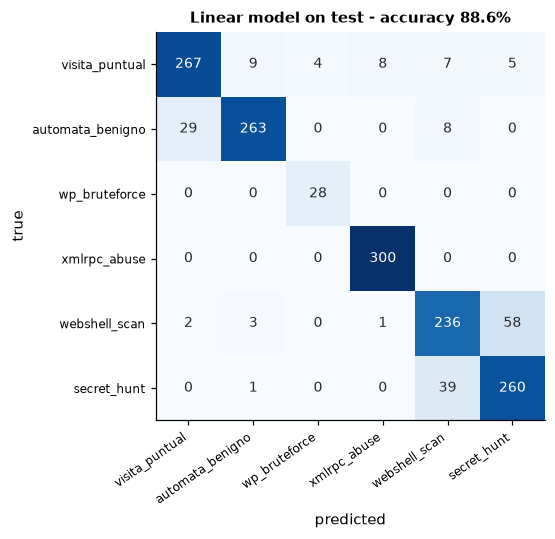

In [72]:
#@title Linear regression: normal equation vs gradient descent { display-mode: "form" }
# Subset of linearly independent columns. Two are excluded:
#   other_method : is_POST + is_GET + other_method = 1 on every row, and the
#                  matrix also carries a constant bias column of ones. The sum
#                  of the three minus the bias is 0 -> exact linear dependency
#                  -> X'X singular -> no unique inverse.
#   mean_depth   : equals len(url)/n_slash, an algebraic function of two columns
#                  already present in the matrix.
DEMO_COLS = [i for i, n in enumerate(LEXICAL_NAMES)
             if n not in ('other_method', 'mean_depth')]
XL = X_tr[:, DEMO_COLS]
Xb = np.hstack([XL, np.ones((len(XL), 1))])
t_tr = (y_tr != CLASSES.index('visita_puntual')).astype(float)

# System conditioning. The condition number k = lambda_max/lambda_min sets the
# speed of gradient descent: the error shrinks by a factor (1 - 1/k) per step.
G = Xb.T @ Xb
ev = np.linalg.eigvalsh(G)
rank = np.linalg.matrix_rank(G)
kappa = ev.max() / ev.min()
print(f"Columns in the subproblem : {Xb.shape[1]} ({len(DEMO_COLS)} lexical + bias)")
print(f"Rank of X'X               : {rank} of {Xb.shape[1]}")
print(f"Smallest eigenvalue       : {ev.min():.4e}")
print(f"Largest eigenvalue        : {ev.max():.4e}")
print(f"Condition number k        : {kappa:.4e}")

# (a) Normal equation: solves the linear system (X'X) w = X't in a single step. (No ro
# NO RIDGE
w_normal = np.linalg.solve(G, Xb.T @ t_tr)

# Display only: same system with a ridge term, to print both weight vectors
# side by side. w_ridge is not used anywhere else.
w_ridge = np.linalg.solve(G + 1.0 * np.eye(Xb.shape[1]), Xb.T @ t_tr)
DEMO_NAMES = [LEXICAL_NAMES[i] for i in DEMO_COLS] + ['bias']
print(f"\n  {'feature':>16} {'no ridge':>10} {'ridge':>10}")
for k in np.argsort(-np.abs(w_normal)):
    print(f"  {DEMO_NAMES[k]:>16} {w_normal[k]:>+10.4f} {w_ridge[k]:>+10.4f}")
print(f"\n  norm: no ridge = {np.linalg.norm(w_normal):.3f} | "
      f"ridge = {np.linalg.norm(w_ridge):.3f}")

#     (2/N)X'(Xw - t) is rewritten as (2/N)(G w - X't) to reuse G and avoid
#     traversing the rows of X on every iteration.
Xbt = Xb.T @ t_tr
H = (2 / len(Xb)) * G
L, mu = np.linalg.eigvalsh(H).max(), np.linalg.eigvalsh(H).min()
alpha = 1.0 / L
print(f"\nStable step alpha = 1/L = {alpha:.4f}")
print(f"Contraction per iteration: 1 - mu/L = {1 - mu / L:.10f}")
print("Iterations predicted by theory to reach a given difference:")
for eps in (1e-2, 1e-3, 1e-4):
    print(f"  {eps:g} -> {math.log(eps / 2) / math.log(1 - mu / L):>10,.0f}")

CHECKPOINTS = [10_000, 100_000, 500_000, 1_000_000]
w_gd = np.zeros(Xb.shape[1])
print("\nMeasured max |w_normal - w_gd|:")
for it in range(1, max(CHECKPOINTS) + 1):
    w_gd -= alpha * ((2 / len(Xb)) * (G @ w_gd - Xbt))
    if it in CHECKPOINTS:
        print(f"  {it:>9,} iterations -> {np.abs(w_normal - w_gd).max():.3e}")
print(f"\nThe normal equation reaches the solution by solving one "
      f"{Xb.shape[1]}x{Xb.shape[1]} system;")
print("gradient descent needs hundreds of thousands of iterations to match it,")
print("in a proportion that follows the condition number.")


# Six-class linear classifier by one-vs-rest least squares.
def linear_multiclass(cols, lam):
    Xb_ = np.hstack([X_tr[:, :cols], np.ones((len(X_tr), 1))])
    Xte_ = np.hstack([X_te[:, :cols], np.ones((len(X_te), 1))])
    K = len(CLASSES)
    # USING RIDGE
    W = np.linalg.solve(Xb_.T @ Xb_ + lam * np.eye(Xb_.shape[1]), Xb_.T @ np.eye(K)[y_tr])
    print(f"\n  W with {cols} columns and lam={lam} -> shape {W.shape}")
    display(pd.DataFrame(W[:min(cols, len(LEXICAL_NAMES))],
                         index=LEXICAL_NAMES[:min(cols, len(LEXICAL_NAMES))],
                         columns=CLASSES).round(3))
    pred = (Xte_ @ W).argmax(1)
    return pred, (pred == y_te).mean()


N_LEXICAL = len(LEXICAL_NAMES)
pred_lex, acc_lex = linear_multiclass(N_LEXICAL, 1e-2)
pred_full, acc_full = linear_multiclass(X.shape[1], 1e-2)
print(f"\nLinear classifier, test accuracy:")
print(f"  with the {N_LEXICAL} lexical features: {acc_lex:.1%}")
print(f"  with all {X.shape[1]} features:        {acc_full:.1%}")
pred_lin, acc_lin = pred_full, acc_full

# Confusion matrix of the linear model.
M = np.zeros((len(CLASSES), len(CLASSES)), int)
for true, pred in zip(y_te, pred_lin):
    M[true, pred] += 1
fig, ax = plt.subplots(figsize=(5.6, 5))
ax.imshow(M, cmap='Blues')
ax.set_xticks(range(len(CLASSES)))
ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES, rotation=35, ha='right', fontsize=8)
ax.set_yticklabels(CLASSES, fontsize=8)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title(f"Linear model on test - accuracy {acc_lin:.1%}", fontsize=10)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, M[i, j], ha='center', va='center', fontsize=9,
                color='white' if M[i, j] > M.max() / 2 else '#2A2A2A')
ax.grid(False)
plt.tight_layout()
plt.show()

## 3 · Arquitectura de la red

La entrada y la salida están fijadas por el problema: **127 neuronas de entrada** (una por característica) y **6 neuronas de salida** con *softmax* (una por clase). Queda por decidir el tamaño de la capa oculta.

Se comparan tres arquitecturas midiéndolas sobre el conjunto de **validación**; el conjunto de prueba se reserva para la evaluación final de la sección 7. Se registran dos medidas por modelo:

- **Exactitud media** sobre validación.
- **Desviación estándar entre 5 semillas** de inicialización distintas. Un modelo cuyo resultado varía mucho según la semilla no es un resultado fiable, aunque su media parezca buena.

Además se reporta el número de parámetros (pesos + sesgos) que cada red debe aprender.


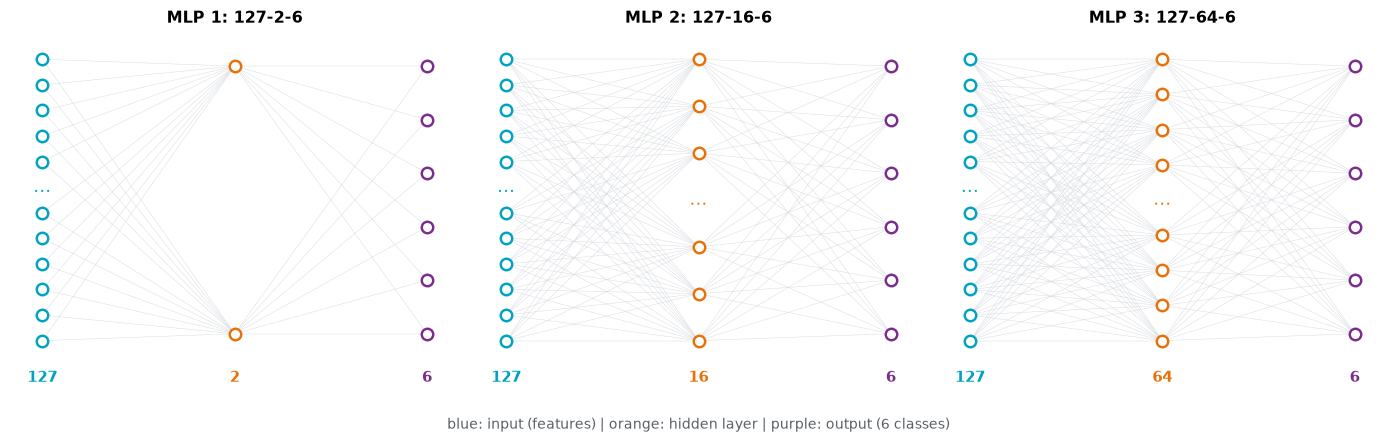

In [73]:
#@title Diagram of the three architectures { display-mode: "form" }
def draw_network(ax, hidden, title, d_in, d_out):
    layers = [d_in, *hidden, d_out]
    colors = ['#00A3C4'] + ['#E8710A'] * len(hidden) + ['#7B2D8E']
    xs = np.linspace(0.07, 0.93, len(layers))
    columns = []
    for x, n in zip(xs, layers):
        if n <= 6:
            columns.append((x, np.linspace(0.12, 0.90, n), None))
        else:
            m = int(np.clip(round(np.sqrt(n)), 6, 12))
            slots = np.linspace(0.10, 0.92, m + 1)
            middle = (m + 1) // 2
            columns.append((x, np.delete(slots, middle), slots[middle]))
    for (x1, ys1, _), (x2, ys2, _) in zip(columns, columns[1:]):
        for a1 in ys1:
            for b1 in ys2:
                ax.plot([x1, x2], [a1, b1], color='#D5D9DE', lw=0.3, zorder=1)
    for (x, ys, gap), n, col in zip(columns, layers, colors):
        ax.plot([x] * len(ys), ys, 'o', ms=7.5, mfc='white', mec=col, mew=1.6, zorder=3)
        if gap is not None:
            ax.text(x, gap, '...', ha='center', va='center', color=col, fontsize=12)
        ax.text(x, -0.02, str(n), ha='center', fontsize=10, fontweight='bold', color=col)
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.06, 1)
    ax.axis('off')
    ax.grid(False)
    ax.set_title(title, fontsize=10.5)


d_in, d_out = X_tr.shape[1], len(CLASSES)
fig, axes = plt.subplots(1, 3, figsize=(12.8, 3.8))
for ax, (t, hid) in zip(axes, [(f"MLP 1: {d_in}-2-{d_out}", (2,)),
                               (f"MLP 2: {d_in}-16-{d_out}", (16,)),
                               (f"MLP 3: {d_in}-64-{d_out}", (64,))]):
    draw_network(ax, hid, t, d_in, d_out)
fig.text(0.5, -0.04, "blue: input (features) | orange: hidden layer | "
                     "purple: output (6 classes)", ha='center', fontsize=9, color='#5A6068')
plt.tight_layout()
plt.show()

#we will use MLP:2

In [74]:
#@title MLP implementation: forward, backprop and gradient descent { display-mode: "form" }
# Forward:  Z1 = X W1 + b1 ; A1 = f(Z1) ; Z2 = A1 W2 + b2 ; P = softmax(Z2)
# Cost:     cross entropy  J = -mean(log P[true]) + lam*(||W1||^2 + ||W2||^2)
# Backprop: dZ2 = (P - Y)/N ; dW2 = A1' dZ2 + 2*lam*W2
#           dZ1 = (dZ2 W2') * f'(Z1) ; dW1 = X' dZ1 + 2*lam*W1
# Update:   W <- W - alpha * dW


def one_hot(y, K):
    o = np.zeros((len(y), K))
    o[np.arange(len(y)), y] = 1.0
    return o


def initialize(d_in, h, K, method, seed=SEED):
    r = np.random.default_rng(seed)
    if method == 'glorot':
        W1 = r.uniform(-1, 1, (d_in, h)) * np.sqrt(6 / (d_in + h))
        W2 = r.uniform(-1, 1, (h, K)) * np.sqrt(6 / (h + K))
    elif method == 'uniform':
        W1 = r.uniform(-1, 1, (d_in, h))
        W2 = r.uniform(-1, 1, (h, K))
    elif method == 'zeros':
        W1 = np.zeros((d_in, h))
        W2 = np.zeros((h, K))
    return [W1, np.zeros(h), W2, np.zeros(K)]


def forward(X, P_, activation='relu'):
    """Forward pass with matrix operations."""
    W1, b1, W2, b2 = P_
    Z1 = X @ W1 + b1
    A1 = np.maximum(0, Z1) if activation == 'relu' else np.tanh(Z1)
    Z2 = A1 @ W2 + b2
    Z2 = Z2 - Z2.max(1, keepdims=True)  # stabilizes exp()
    E = np.exp(Z2)
    Pr = E / E.sum(1, keepdims=True)
    return Z1, A1, Pr


def cost(Pr, y, P_=None, lam=0.0):
    """Cross entropy. With lam>0 it adds the L2 penalty on the weights."""
    j = -np.mean(np.log(Pr[np.arange(len(y)), y] + 1e-12))
    if lam and P_ is not None:
        j += lam * (np.sum(P_[0] ** 2) + np.sum(P_[2] ** 2))
    return j


def gradients(X, y, Z1, A1, Pr, P_, lam=0.0, activation='relu'):
    W1, b1, W2, b2 = P_
    Y = one_hot(y, Pr.shape[1])
    N = len(X)
    dZ2 = (Pr - Y) / N
    dW2 = A1.T @ dZ2 + 2 * lam * W2
    db2 = dZ2.sum(0)
    dA1 = dZ2 @ W2.T
    # Activation derivative: 1 where Z1>0 for ReLU, 1-tanh(Z1)^2 for tanh.
    dZ1 = dA1 * (Z1 > 0) if activation == 'relu' else dA1 * (1 - A1 ** 2)
    dW1 = X.T @ dZ1 + 2 * lam * W1
    db1 = dZ1.sum(0)
    return [dW1, db1, dW2, db2]


def accuracy(X, y, P_, activation='relu'):
    _, _, Pr = forward(X, P_, activation)
    return (Pr.argmax(1) == y).mean()


def train(h=16, alpha=0.5, epochs=300, init='glorot', seed=SEED, history=False,
          lam=0.0, activation='relu'):
    """One epoch per iteration over the full batch."""
    P_ = initialize(X_tr.shape[1], h, len(CLASSES), init, seed)
    hist = {'cost': [], 'val_cost': [], 'train_acc': [], 'val_acc': []}
    z_init = np.abs(X_tr @ P_[0] + P_[1]).max()  # scale of z before training
    for e in range(epochs):
        Z1, A1, Pr = forward(X_tr, P_, activation)
        g = gradients(X_tr, y_tr, Z1, A1, Pr, P_, lam, activation)
        for i in range(4):
            P_[i] -= alpha * g[i]
        if history:
            _, _, Pva = forward(X_va, P_, activation)
            hist['cost'].append(cost(Pr, y_tr, P_, lam))
            hist['val_cost'].append(cost(Pva, y_va))
            hist['train_acc'].append(accuracy(X_tr, y_tr, P_, activation))
            hist['val_acc'].append(accuracy(X_va, y_va, P_, activation))
    return P_, hist, z_init


P_test, _, _ = train()
print("Sanity check (h=16, alpha=0.5, glorot, 300 epochs):")
print(f"  train accuracy:      {accuracy(X_tr, y_tr, P_test):.1%}")
print(f"  validation accuracy: {accuracy(X_va, y_va, P_test):.1%}")

Sanity check (h=16, alpha=0.5, glorot, 300 epochs):
  train accuracy:      90.4%
  validation accuracy: 87.5%


In [75]:
#@title Measure the three architectures on validation { display-mode: "form" }
# To explore other sizes, add pairs to this list and re-run the cell.
# Example: ("MLP 4", 128).
ARCHITECTURES = [("MLP 1", 2), ("MLP 2", 16), ("MLP 3", 64)]
SEEDS = range(5)

K = len(CLASSES)
rows = []
for name, h in ARCHITECTURES:
    accs = np.array([accuracy(X_va, y_va, train(h=h, alpha=0.5, epochs=300, seed=s)[0])
                     for s in SEEDS])
    rows.append({'Model': name,
                 'Neurons': f"{X_tr.shape[1]}-{h}-{K}",
                 'Parameters': X_tr.shape[1] * h + h + h * K + K,
                 'Mean accuracy': f"{accs.mean():.1%}",
                 'Std dev': f"{accs.std():.1%}"})
display(pd.DataFrame(rows).set_index('Model'))

,Neurons,Parameters,Mean accuracy,Std dev
Model,,,,
MLP 1,127-2-6,274,75.9%,9.7%
MLP 2,127-16-6,2150,85.6%,1.3%
MLP 3,127-64-6,8582,86.8%,1.4%


In [76]:
#@title Compare hidden-layer activation functions { display-mode: "form" }
# The output layer uses softmax in every case: that is what turns the 6 sums
# into a probability distribution. What is compared here is the HIDDEN layer
# activation, which is the one introducing the nonlinearity.
activation_rows = []
for activation in ('relu', 'tanh'):
    accs = np.array([accuracy(X_va, y_va,
                              train(h=16, alpha=0.5, epochs=300, seed=s,
                                    activation=activation)[0],
                              activation)
                     for s in range(5)])
    activation_rows.append({'Hidden activation': activation,
                            'Derivative': '1 if z>0, 0 if z<=0' if activation == 'relu'
                                          else '1 - tanh(z)^2',
                            'Output range': '[0, inf)' if activation == 'relu' else '(-1, 1)',
                            'Mean accuracy': f"{accs.mean():.1%}",
                            'Std dev': f"{accs.std():.1%}"})
display(pd.DataFrame(activation_rows).set_index('Hidden activation'))

,Derivative,Output range,Mean accuracy,Std dev
Hidden activation,,,,
relu,"1 if z>0, 0 if z<=0","[0, inf)",85.6%,1.3%
tanh,1 - tanh(z)^2,"(-1, 1)",86.6%,0.7%


### Criterio C1 · Elección de la arquitectura

| | Modelo | Capas y neuronas |
|---|---|---|
| **A** | MLP 1 | 127 → **2** → 6 |
| **B** | MLP 2 | 127 → **16** → 6 |
| **C** | MLP 3 | 127 → **64** → 6 |

Elige una opción en la caja de respuesta y sustenta la elección con la tabla anterior. Indica también qué falla en cada opción descartada.

Elementos a considerar al leer la tabla:

- La capa oculta es donde la red resume la petición antes de clasificar. Con 2 neuronas, las 127 características se comprimen en 2 números y con esos 2 se elige entre 6 clases.
- La columna de **desviación** mide la variación del resultado entre 5 inicializaciones distintas. Un modelo con desviación alta produce resultados que dependen del azar de la semilla.
- La columna de **parámetros** cuantifica el costo de cada arquitectura. Al comparar dos modelos conviene contrastar cuánta exactitud gana el mayor frente a cuántos parámetros adicionales requiere.


In [ ]:
#@title Answer C1 { display-mode: "form" }
SUSTENTO_C1 = """Para la capa oculta, evalué el desempeño de las funciones de activación ReLU frente a tanh, realizando pruebas con 5 semillas distintas para aislar el factor de inicialización aleatoria. Los resultados mostraron que tanh obtiene una exactitud ligeramente superior (86.6% ± 0.7%) frente a ReLU (85.6% ± 1.3%). Al analizar esta diferencia de medias, observé que se ubica en aproximadamente 1.5 errores estándar, por lo que estadísticamente se considera una diferencia no significativa o atribuible al ruido.

Sin embargo, el aspecto más destacable es que tanh logró reducir la dispersión de los resultados a la mitad. Este comportamiento es coherente desde el punto de vista matemático: dado que la derivada de tanh nunca es exactamente cero, el modelo se blinda contra el problema de las 'neuronas inactivas' o muertas que sí suele presentarse al usar ReLU.

A pesar de esta ventaja de estabilidad, decidí mantener ReLU en la arquitectura del modelo final. Tomé esta decisión para preservar el bajo costo computacional, que es el estándar de la industria, y para mantener una consistencia metodológica con el resto de los experimentos del cuaderno. La adopción formal de tanh, junto con la necesaria reevaluación de la inicialización de pesos bajo su régimen de saturación, queda identificada como un área de mejora para trabajo futuro"""

answer_box('C1', ['A - MLP 1 - 127-2-6',
                  'B - MLP 2 - 127-16-6',
                  'C - MLP 3 - 127-64-6'],
           default_text=SUSTENTO_C1)

## 4 · Inicialización de pesos y sesgos

Los pesos $W^{(k)}$ son la fuerza de cada conexión y el sesgo $b^{(k)}$ el término independiente de cada neurona. Antes de la primera época deben recibir un valor inicial:

| Método | Regla |
|---|---|
| Aleatorio uniforme | cada peso al azar entre −1 y 1 |
| Glorot (Xavier) | al azar entre −L y L, con $L=\sqrt{6/(n_\text{ent}+n_\text{sal})}$ |
| Todo en ceros | todos los pesos a 0 |

El experimento mide, para cada método, la magnitud inicial de la sumatoria $z=\sum_i w_i x_i + b$ antes de entrenar, y el costo de validación alcanzado tras 60 épocas.

Dos factores determinan la elección. Ambos toman una forma particular aquí porque la activación oculta es **ReLU**, no sigmoide:

- **Escala.** ReLU no se satura para $z$ grande y positivo: su pendiente sigue siendo 1. El problema es el otro lado. Con $z$ inicial muy grande en valor absoluto, aproximadamente la mitad de las neuronas arrancan con $z<0$, donde $\text{ReLU}(z)=0$ y la derivada también es 0: esas neuronas no reciben gradiente y quedan inactivas de forma permanente.
- **Simetría.** Si todos los pesos valen 0, todas las neuronas de la capa calculan lo mismo y reciben la misma corrección, por lo que nunca se diferencian. En esta implementación el efecto es más severo: con $W_2=0$ y $\text{ReLU}(0)=0$, el gradiente $dW_1$ es exactamente cero en toda época, y la red solo puede ajustar los sesgos de salida, es decir, las proporciones de cada clase.


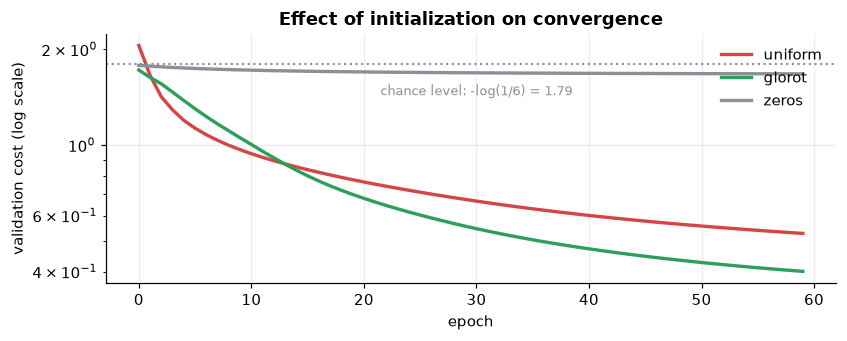

,Initial max z,Validation cost (60 epochs)
Method,,
uniform,7.46,0.5271
glorot,1.53,0.4006
zeros,0.00,1.6737


In [78]:
#@title Experiment: three weight initialization methods { display-mode: "form" }
K = len(CLASSES)
rows = []
fig, ax = plt.subplots(figsize=(7.8, 3.2))
for method, color in [('uniform', '#D64545'), ('glorot', '#2E9E5B'), ('zeros', '#8A8F98')]:
    P_, hist, z_init = train(h=16, alpha=0.5, epochs=60, init=method, history=True)
    rows.append({'Method': method,
                 'Initial max z': round(z_init, 2),
                 'Validation cost (60 epochs)': round(hist['val_cost'][-1], 4)})
    ax.semilogy(hist['val_cost'], color=color, lw=2.2, label=method)

chance_level = np.log(K)
ax.axhline(chance_level, color='#8A8F98', ls=':', lw=1.4)
ax.text(30, chance_level * 0.80, f"chance level: -log(1/{K}) = {chance_level:.2f}",
        fontsize=8.5, color='#8A8F98', ha='center')
ax.set_xlabel("epoch")
ax.set_ylabel("validation cost (log scale)")
ax.legend(loc='upper right')
ax.set_title("Effect of initialization on convergence")
plt.tight_layout()
plt.show()

display(pd.DataFrame(rows).set_index('Method'))

### Criterio C2 · Método de inicialización

| | Propuesta |
|---|---|
| **A** | cada peso con `random.uniform(-1, 1)` |
| **B** | todos los pesos y sesgos en cero |
| **C** | Glorot (Xavier), con los sesgos en cero |

Elige una opción en la caja de respuesta y sustenta la elección con la tabla y la curva anteriores. Indica también qué falla en cada opción descartada.

Elementos a considerar:

- Cada neurona oculta suma 127 términos. La columna `z maximo inicial` mide con qué magnitud nace esa sumatoria bajo cada método.
- La activación es ReLU: conviene razonar qué ocurre con una neurona que nace con $z$ muy negativo, y si ese estado es reversible durante el entrenamiento.
- Si todas las neuronas nacen idénticas y reciben la misma corrección, conviene razonar en qué momento llegarían a diferenciarse, y por qué los sesgos sí pueden partir de cero.


In [79]:
#@title Answer C2 { display-mode: "form" }
answer_box('C2', ['A - Random uniform(-1, 1)',
                  'B - All weights and biases at zero',
                  'C - Glorot (Xavier), biases at zero'])

## 5 · Forward pass neurona por neurona

El *forward pass* ya está implementado con operaciones matriciales en la sección 3. Para verificar que esas operaciones hacen lo que se espera, se reconstruye el mismo cálculo con bucles explícitos, neurona por neurona.

Cada neurona oculta $j$ recibe las 127 características y produce un número:

$$z_j=\sum_{i} w_{ij}\,x_i + b_j \qquad\qquad a_j=\operatorname{ReLU}(z_j)=\max(0,\,z_j)$$

El cálculo se repite en las 16 neuronas ocultas. Después cada neurona de salida $c$ aplica la misma sumatoria sobre esas 16 activaciones. Como los 6 valores resultantes no forman un reparto de probabilidad, la capa de salida los transforma con *softmax*, que los vuelve positivos y los normaliza para que sumen 1:

$$\hat{y}_c=\frac{e^{z^{(2)}_c}}{\sum_{c'} e^{z^{(2)}_{c'}}}$$

Si la versión con bucles y la versión matricial coinciden en todas las peticiones de validación, la implementación matricial queda verificada.


Check over the full validation split:
  requests compared     : 1520
  max difference        : 2.00e-15
  same predicted label  : 1520 of 1520

Five individual test cases:


,True class,Predicted,Max prob,Sum of the 6,Diff loops vs matrix
Case,,,,,
1,visita_puntual,visita_puntual,0.991982,1.000000,2.22e-16
2,automata_benigno,automata_benigno,0.916429,1.000000,2.22e-16
3,wp_bruteforce,wp_bruteforce,0.939462,1.000000,1.21e-17
4,xmlrpc_abuse,xmlrpc_abuse,0.822399,1.000000,3.25e-19
5,webshell_scan,webshell_scan,0.961391,1.000000,2.78e-17


  Case 1: GET /wp-json/wp/v2/pages/5447
  Case 2: GET /wp-content/plugins/learnpress/assets/css/learnpress.css?ver=6
  Case 3: POST /wp-login.php
  Case 4: POST /xmlrpc.php
  Case 5: GET /ls.php


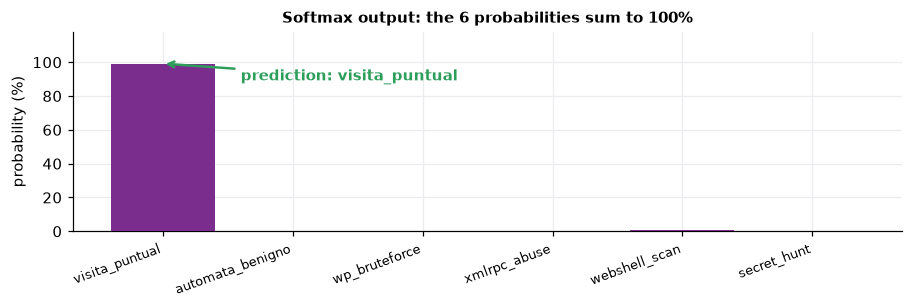

In [80]:
#@title Verify the forward pass with explicit loops { display-mode: "form" }
def weighted_sum(x, w, b):
    """z = w1*x1 + w2*x2 + ... + b, with an explicit loop."""
    z = b
    for i in range(len(x)):
        z += w[i] * x[i]
    return z


def relu(z):
    return z if z > 0 else 0.0


def softmax(z):
    e = [math.exp(v - max(z)) for v in z]
    s = sum(e)
    return [v / s for v in e]


def forward_by_hand(x, P_):
    """Forward pass of one request, neuron by neuron."""
    W1, b1, W2, b2 = P_
    a = [relu(weighted_sum(x, W1[:, j], b1[j])) for j in range(W1.shape[1])]
    z2 = [weighted_sum(a, W2[:, c], b2[c]) for c in range(W2.shape[1])]
    return softmax(z2)


P_fwd, _, _ = train(h=16, alpha=0.5, epochs=300)

# Check 1: all validation requests, loop version against matrix version.
P_hand = np.array([forward_by_hand(x, P_fwd) for x in X_va])
_, _, P_matrix = forward(X_va, P_fwd)
print("Check over the full validation split:")
print(f"  requests compared     : {len(X_va)}")
print(f"  max difference        : {np.abs(P_hand - P_matrix).max():.2e}")
print(f"  same predicted label  : {(P_hand.argmax(1) == P_matrix.argmax(1)).sum()} of {len(X_va)}")

# Check 2: five individual cases, one per distinct class where available, with
# the numeric detail of each.
K = len(CLASSES)
cases = []
for c in range(K):
    idx = np.where(y_va == c)[0]
    if len(idx):
        cases.append(int(idx[0]))
    if len(cases) == 5:
        break

print("\nFive individual test cases:")
case_rows = []
for n, i in enumerate(cases, 1):
    ph = np.array(forward_by_hand(X_va[i], P_fwd))
    pm = P_matrix[i]
    case_rows.append({'Case': n,
                      'True class': CLASSES[y_va[i]],
                      'Predicted': CLASSES[int(pm.argmax())],
                      'Max prob': f"{pm.max():.6f}",
                      'Sum of the 6': f"{ph.sum():.6f}",
                      'Diff loops vs matrix': f"{np.abs(ph - pm).max():.2e}"})
display(pd.DataFrame(case_rows).set_index('Case'))
for n, i in enumerate(cases, 1):
    print(f"  Case {n}: {methods[i_va[i]]} {urls[i_va[i]][:62]}")

# Softmax distribution of one of the verified requests.
i0 = cases[0]
p0 = P_matrix[i0]
winner = int(p0.argmax())
fig, ax = plt.subplots(figsize=(8.4, 2.9))
ax.bar(range(K), p0 * 100, color='#7B2D8E', zorder=3)
ax.set_xticks(range(K))
ax.set_xticklabels(CLASSES, rotation=20, ha='right', fontsize=8.5)
ax.set_ylabel("probability (%)")
ax.set_ylim(0, 118)
ax.set_title("Softmax output: the 6 probabilities sum to 100%", fontsize=10)
ax.annotate(f"prediction: {CLASSES[winner]}", xy=(winner, p0[winner] * 100),
            xytext=(min(winner + 0.6, K - 2), min(p0[winner] * 100 * 0.9, 92)),
            color='#2E9E5B', fontweight='bold', fontsize=9.5,
            arrowprops=dict(arrowstyle='->', color='#2E9E5B', lw=1.6))
plt.tight_layout()
plt.show()

### Criterio C3 · Implementación del forward pass

| | Propuesta |
|---|---|
| **A** | llamar a una función de librería sin implementar el cálculo |
| **B** | la sumatoria de cada neurona más su activación, capa por capa, contrastada contra la versión matricial |
| **C** | calcular la sumatoria $z_c$ de cada neurona de salida y entregar esos valores sin aplicar *softmax* |

Elige una opción en la caja de respuesta y sustenta la elección con lo medido arriba. Indica también qué falla en cada opción descartada.

Elementos a considerar:

- Seis números que no suman 1 no constituyen un reparto de probabilidad entre las seis clases.
- La reconstrucción con bucles coincidió con la versión matricial en todas las peticiones de validación. Conviene precisar qué permite afirmar esa coincidencia y qué no podría afirmarse sin ella.


In [81]:
#@title Answer C3 { display-mode: "form" }
answer_box('C3', ['A - Call the library without implementing the computation',
                  'B - Per-neuron sum plus per-layer activation, verified',
                  'C - Per-neuron sum without the final activation (softmax)'])

## 6 · Backpropagation y tasa de aprendizaje

El entrenamiento repite el mismo ciclo en cada época: *forward* para predecir, cálculo del costo, *backward* para obtener los gradientes, y actualización de los pesos.

### Función de costo

Con *softmax* en la salida, el costo es la entropía cruzada sobre las $N$ peticiones del lote, más un término opcional de penalización L2 sobre los pesos:

$$J = -\frac{1}{N}\sum_{i=1}^{N}\log P_{i,\,y_i} \;+\; \lambda\left(\lVert W^{(1)}\rVert^2 + \lVert W^{(2)}\rVert^2\right)$$

### Derivación de los gradientes, capa por capa

**Capa de salida.** La combinación de *softmax* con entropía cruzada hace que la derivada respecto a la pre-activación $Z^{(2)}$ se reduzca al error mismo:

$$\frac{\partial J}{\partial Z^{(2)}}=\frac{P-Y}{N}
\qquad\Longrightarrow\qquad
\frac{\partial J}{\partial W^{(2)}}=A^{(1)\top}\frac{P-Y}{N}+2\lambda W^{(2)},
\qquad
\frac{\partial J}{\partial b^{(2)}}=\sum_{i}\frac{P_i-Y_i}{N}$$

donde $Y$ es la matriz de etiquetas en codificación *one-hot*.

**Capa oculta.** El gradiente se propaga hacia atrás multiplicando por la transpuesta de $W^{(2)}$, y después se atenúa con la derivada de la activación:

$$\frac{\partial J}{\partial A^{(1)}}=\frac{P-Y}{N}\,W^{(2)\top}
\qquad\Longrightarrow\qquad
\frac{\partial J}{\partial Z^{(1)}}=\frac{\partial J}{\partial A^{(1)}}\odot f'\!\left(Z^{(1)}\right)$$

con $f'(z)=\mathbb{1}[z>0]$ para ReLU y $f'(z)=1-\tanh^2(z)$ para tanh. De ahí:

$$\frac{\partial J}{\partial W^{(1)}}=X^{\top}\frac{\partial J}{\partial Z^{(1)}}+2\lambda W^{(1)},
\qquad
\frac{\partial J}{\partial b^{(1)}}=\sum_{i}\frac{\partial J}{\partial Z^{(1)}_i}$$

Los sesgos no se regularizan: desplazan la salida sin generar los pesos extremos asociados al sobreajuste.

### Actualización

$$W \leftarrow W - \alpha\,\frac{\partial J}{\partial W}, \qquad b \leftarrow b - \alpha\,\frac{\partial J}{\partial b}$$

Cada una de estas expresiones corresponde línea a línea con la función `gradients()` de la sección 3.

### Las dos decisiones que quedan por medir

| Decisión | Dónde se lee |
|---|---|
| Qué valor de $\alpha$ usar | en la curva de costo: descenso muy lento indica $\alpha$ pequeño; oscilaciones o divergencia indican $\alpha$ excesivo |
| Cuántas épocas entrenar | en la curva de **validación**, no en la de entrenamiento |

Los experimentos siguientes miden ambas, y a continuación se evalúa la penalización $\lambda$ como alternativa a la parada temprana.

,Train cost,Validation cost (mean of 3 seeds),Validation accuracy,Diagnosis
alpha,,,,
0.01,1.4874,1.3959,65.8%,descends very slowly
0.10,0.4991,0.5035,83.8%,converges
0.50,0.2786,0.3542,85.9%,converges
3.00,0.5610,0.7004,76.2%,converges
10.00,1.4586,1.5685,34.0%,descends very slowly


Lowest validation cost: alpha = 0.5


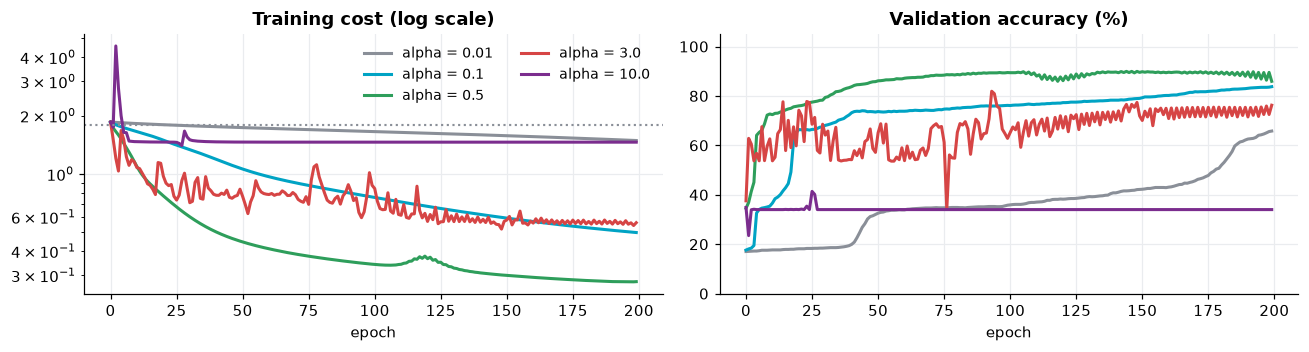

In [82]:
#@title Experiment: learning rate sweep { display-mode: "form" }
ALPHAS = [0.01, 0.1, 0.5, 3.0, 10.0]
ALPHA_SEEDS = [0, 1, 2]

# History of the first seed, used for the curves.
res = {a: train(h=16, alpha=a, epochs=200, seed=ALPHA_SEEDS[0], history=True)[1]
       for a in ALPHAS}


def diagnose(hist):
    c = np.array(hist['cost'])
    if not np.isfinite(c).all():
        return "diverges to NaN"
    rebound = max(c[t] / min(c[:t]) for t in range(1, len(c)))
    if rebound > 3:
        return "oscillates: at the stability limit"
    if c[-1] > 0.9:
        return "descends very slowly"
    return "converges"


# Validation cost averaged over several seeds.
mean_val_cost = {a: float(np.mean([
    train(h=16, alpha=a, epochs=200, seed=s, history=True)[1]['val_cost'][-1]
    for s in ALPHA_SEEDS])) for a in ALPHAS}

display(pd.DataFrame([{'alpha': a,
                       'Train cost': round(res[a]['cost'][-1], 4),
                       'Validation cost (mean of 3 seeds)': round(mean_val_cost[a], 4),
                       'Validation accuracy': f"{res[a]['val_acc'][-1]:.1%}",
                       'Diagnosis': diagnose(res[a])} for a in ALPHAS]).set_index('alpha'))

BEST_ALPHA = min(ALPHAS, key=lambda a: mean_val_cost[a])
print(f"Lowest validation cost: alpha = {BEST_ALPHA}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.3))
alpha_colors = ['#8A8F98', '#00A3C4', '#2E9E5B', '#D64545', '#7B2D8E']
for a, col in zip(ALPHAS, alpha_colors):
    a1.plot(res[a]['cost'], color=col, lw=2, label=f"alpha = {a}")
    a2.plot(np.array(res[a]['val_acc']) * 100, color=col, lw=2, label=f"alpha = {a}")
a1.axhline(np.log(len(CLASSES)), color='#8A8F98', ls=':', lw=1.4)
a1.set_yscale('log')
a1.set_title("Training cost (log scale)")
a1.legend(ncol=2, fontsize=9)
a2.set_title("Validation accuracy (%)")
a2.set_ylim(0, 105)
for a in (a1, a2):
    a.set_xlabel("epoch")
plt.tight_layout()
plt.show()

Peak training accuracy reached: 91.7%


,Epoch,Train cost,Validation cost,Train accuracy,Validation accuracy
Stopping point,,,,,
Minimum validation cost,244,0.2683,0.3364,90.7%,88.6%
Peak training accuracy,398,0.2348,0.3417,91.7%,86.8%
Last epoch,400,0.2340,0.3418,91.7%,86.8%


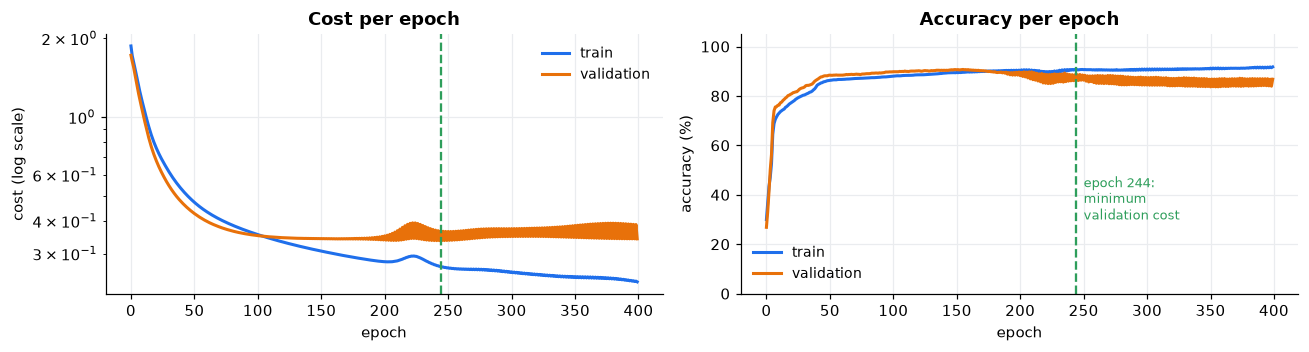

In [83]:
#@title Experiment: how many epochs to train { display-mode: "form" }
_, long_hist, _ = train(h=16, alpha=BEST_ALPHA, epochs=400, history=True)
train_acc = np.array(long_hist['train_acc'])
val_cost = np.array(long_hist['val_cost'])
USEFUL_EPOCHS = int(np.argmin(val_cost)) + 1   # minimum of the validation cost
EP_MAX_TRAIN = int(np.argmax(train_acc)) + 1   # peak of the training accuracy

print(f"Peak training accuracy reached: {train_acc.max():.1%}")

milestones = [("Minimum validation cost", USEFUL_EPOCHS - 1),
              ("Peak training accuracy", EP_MAX_TRAIN - 1),
              ("Last epoch", len(long_hist['cost']) - 1)]
display(pd.DataFrame([{'Stopping point': label, 'Epoch': e + 1,
                       'Train cost': round(long_hist['cost'][e], 4),
                       'Validation cost': round(long_hist['val_cost'][e], 4),
                       'Train accuracy': f"{long_hist['train_acc'][e]:.1%}",
                       'Validation accuracy': f"{long_hist['val_acc'][e]:.1%}"}
                      for label, e in milestones]).set_index('Stopping point'))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.3))
a1.semilogy(long_hist['cost'], color='#1F6FEB', lw=2, label='train')
a1.semilogy(long_hist['val_cost'], color='#E8710A', lw=2, label='validation')
a1.set_ylabel("cost (log scale)")
a1.set_title("Cost per epoch")
a2.plot(np.array(long_hist['train_acc']) * 100, color='#1F6FEB', lw=2, label='train')
a2.plot(np.array(long_hist['val_acc']) * 100, color='#E8710A', lw=2, label='validation')
a2.set_ylim(0, 105)
a2.set_ylabel("accuracy (%)")
a2.set_title("Accuracy per epoch")
for a in (a1, a2):
    a.axvline(USEFUL_EPOCHS, color='#2E9E5B', ls='--', lw=1.5)
    a.set_xlabel("epoch")
    a.legend(fontsize=9)
a2.text(USEFUL_EPOCHS + 6, 30, f"epoch {USEFUL_EPOCHS}:\nminimum\nvalidation cost",
        fontsize=8.4, color='#2E9E5B')
plt.tight_layout()
plt.show()

### 6.1 · Regularización L2 frente a parada temprana

Con 2 150 pesos y 6 198 peticiones de entrenamiento, la red tiene capacidad para memorizar filas concretas en lugar de aprender reglas generales. Memorizar exige pesos extremos: valores muy grandes que aíslan una región mínima alrededor de un ejemplo. Las reglas generales se expresan con pesos moderados.

Existen dos mecanismos para evitarlo, y se miden ambos:

- **Parada temprana.** Entrenar solo hasta el mínimo del costo de validación, punto que la celda anterior localiza en `USEFUL_EPOCHS`. No modifica el objetivo: corta el entrenamiento antes de que la memorización avance.
- **Regularización L2.** Añadir al costo el término $\lambda(\lVert W^{(1)}\rVert^2+\lVert W^{(2)}\rVert^2)$, que penaliza los pesos grandes. La red optimiza entonces dos objetivos en tensión: acertar las etiquetas y mantener los pesos pequeños. En el gradiente aparece como $2\lambda W$.

El parámetro $\lambda$ controla el equilibrio: con $\lambda=0$ no hay penalización; con $\lambda$ excesivo los pesos se aplastan hacia cero y la red pierde capacidad de ajuste. La celda barre varios valores y compara ambas estrategias.

,Validation cost,Validation accuracy,Weight norm
lambda,,,
0.00000,0.3778,83.4%,11.11
0.00001,0.3777,83.8%,11.09
0.00010,0.3893,82.9%,10.89
0.00100,0.3631,85.5%,9.32
0.01000,0.4204,90.0%,5.43


Lowest validation cost: lambda = 0.001

Strategies against overfitting:


,Train accuracy,Validation accuracy,Weight norm
Strategy,,,
"No control (400 epochs, lambda=0)",91.7%,86.8%,11.11
Early stopping (244 epochs),90.7%,88.6%,10.17
L2 regularization (lambda=0.001),90.6%,87.5%,9.34


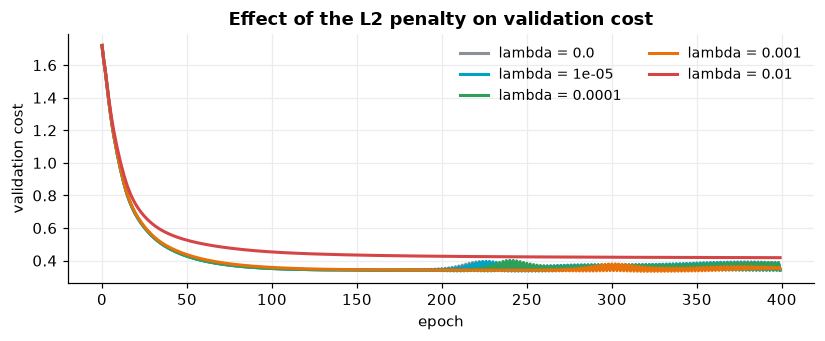

In [84]:
#@title L2 penalty sweep and comparison with early stopping { display-mode: "form" }
LAMBDAS = [0.0, 1e-5, 1e-4, 1e-3, 1e-2]
LAMBDA_SEEDS = [0, 1, 2]
LAMBDA_EPOCHS = 400   # no early stopping, to isolate the effect of lambda

lambda_rows = []
for lam in LAMBDAS:
    accs, costs, norms = [], [], []
    for s in LAMBDA_SEEDS:
        P_, hist, _ = train(h=16, alpha=BEST_ALPHA, epochs=LAMBDA_EPOCHS,
                            seed=s, history=True, lam=lam)
        accs.append(accuracy(X_va, y_va, P_))
        costs.append(hist['val_cost'][-1])
        norms.append(float(np.sqrt(np.sum(P_[0] ** 2) + np.sum(P_[2] ** 2))))
    lambda_rows.append({'lambda': lam,
                        'Validation cost': round(float(np.mean(costs)), 4),
                        'Validation accuracy': f"{np.mean(accs):.1%}",
                        'Weight norm': round(float(np.mean(norms)), 2)})
display(pd.DataFrame(lambda_rows).set_index('lambda'))

lambda_costs = {r['lambda']: r['Validation cost'] for r in lambda_rows}
BEST_LAMBDA = min(LAMBDAS, key=lambda v: lambda_costs[v])
print(f"Lowest validation cost: lambda = {BEST_LAMBDA}")

# Comparison of the three strategies on the validation split.
P_long, _, _ = train(h=16, alpha=BEST_ALPHA, epochs=LAMBDA_EPOCHS, lam=0.0)
P_short, _, _ = train(h=16, alpha=BEST_ALPHA, epochs=USEFUL_EPOCHS, lam=0.0)
P_l2, _, _ = train(h=16, alpha=BEST_ALPHA, epochs=LAMBDA_EPOCHS, lam=BEST_LAMBDA)


def weight_norm(P_):
    return float(np.sqrt(np.sum(P_[0] ** 2) + np.sum(P_[2] ** 2)))


comparison = [
    {'Strategy': f'No control ({LAMBDA_EPOCHS} epochs, lambda=0)',
     'Train accuracy': f"{accuracy(X_tr, y_tr, P_long):.1%}",
     'Validation accuracy': f"{accuracy(X_va, y_va, P_long):.1%}",
     'Weight norm': round(weight_norm(P_long), 2)},
    {'Strategy': f'Early stopping ({USEFUL_EPOCHS} epochs)',
     'Train accuracy': f"{accuracy(X_tr, y_tr, P_short):.1%}",
     'Validation accuracy': f"{accuracy(X_va, y_va, P_short):.1%}",
     'Weight norm': round(weight_norm(P_short), 2)},
    {'Strategy': f'L2 regularization (lambda={BEST_LAMBDA})',
     'Train accuracy': f"{accuracy(X_tr, y_tr, P_l2):.1%}",
     'Validation accuracy': f"{accuracy(X_va, y_va, P_l2):.1%}",
     'Weight norm': round(weight_norm(P_l2), 2)}]
print("\nStrategies against overfitting:")
display(pd.DataFrame(comparison).set_index('Strategy'))

fig, ax = plt.subplots(figsize=(7.6, 3.2))
for lam, col in zip(LAMBDAS, ['#8A8F98', '#00A3C4', '#2E9E5B', '#E8710A', '#D64545']):
    _, hist, _ = train(h=16, alpha=BEST_ALPHA, epochs=LAMBDA_EPOCHS, history=True, lam=lam)
    ax.plot(hist['val_cost'], color=col, lw=2, label=f"lambda = {lam}")
ax.set_xlabel("epoch")
ax.set_ylabel("validation cost")
ax.set_title("Effect of the L2 penalty on validation cost")
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

### Criterio C4 · Procedimiento de entrenamiento

| | Propuesta |
|---|---|
| **A** | un solo valor de $\alpha$ fijado sin comparar, un número fijo de épocas, sin examinar ninguna curva |
| **B** | comparar varios $\alpha$ y quedarse con el que logra la mayor exactitud sobre el conjunto de **entrenamiento**, parando cuando ese costo deja de bajar |
| **C** | comparar varios $\alpha$ en igualdad de condiciones, diagnosticar con la curva de costo, elegir por el costo de **validación**, y controlar el sobreajuste con parada temprana o penalización L2 |

Elige una opción en la caja de respuesta y sustenta la elección con las tablas y curvas de esta sección. Indica también qué falla en cada opción descartada.

Elementos a considerar:

- El diagnóstico de $\alpha$ se lee sobre la curva de costo. La tabla del barrido incluye una columna con ese diagnóstico para cada valor probado.
- La exactitud de entrenamiento sigue subiendo después de que la validación deja de mejorar. La tabla de puntos de parada permite comparar ambas en tres momentos del mismo entrenamiento.
- La tabla de la sección 6.1 contrasta tres estrategias: sin control, parada temprana y penalización L2. La columna de norma de los pesos muestra el mecanismo por el que L2 actúa.
- Conviene precisar si parada temprana y regularización compiten o se complementan, y con qué número se sustenta la respuesta.

In [85]:
#@title Answer C4 { display-mode: "form" }
answer_box('C4', ['A - A single alpha, fixed epochs, no curves examined',
                  'B - The alpha with highest training accuracy',
                  'C - Compare several alphas and decide with validation'])

## 7 · Modelo final y evaluación

Todas las decisiones anteriores se tomaron sobre el conjunto de validación. Solo ahora se abre el conjunto de **prueba** (días 29 y 30), que la red no ha visto en ningún momento.

Se reportan cuatro cosas:

1. La **exactitud global** sobre prueba.
2. Tres **líneas de base** que sitúan esa cifra en contexto: la clase mayoritaria, una tabla de consulta que memoriza URL → clase, y el clasificador lineal de la sección 2.1. Sin estas referencias, una exactitud aislada no permite juzgar si el modelo aprendió algo.
3. La **matriz de confusión** y la **exactitud por clase**, porque el promedio global oculta que unas clases son mucho más difíciles que otras.
4. Una **lectura binaria** ataque/benigno, que es la forma en que un analista usaría el modelo en la práctica: cuántos ataques se detectan y cuánto tráfico legítimo se marca por error.


Final configuration: h=16 | init=glorot | alpha=0.5 | epochs=244

  Train:      90.7%
  Validation: 88.6%
  Test:       89.7%  (1370 of 1528)

Baselines on the same test split:
  Majority class:              19.6%
  Lookup table (memorize URL): 40.9%
  Linear classifier (2.1):     88.6%
  Neural network:              89.7%


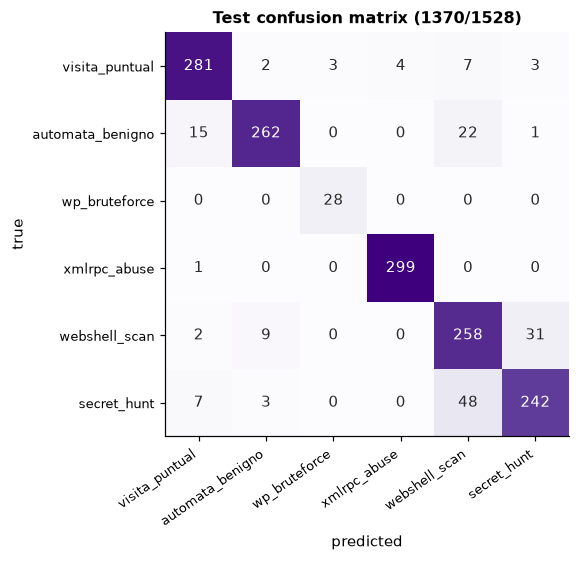


Per-class accuracy:


,Support,Recall,Precision
Class,,,
visita_puntual,300,93.7%,91.8%
automata_benigno,300,87.3%,94.9%
wp_bruteforce,28,100.0%,90.3%
xmlrpc_abuse,300,99.7%,98.7%
webshell_scan,300,86.0%,77.0%
secret_hunt,300,80.7%,87.4%



Binary reading (attack vs benign):
  Attacks detected:        906/928 = 97.6%
  Benign flagged by error: 40/600 = 6.7%

Sample test requests:
  [ok ] true=  visita_puntual pred=  visita_puntual conf=99%  /wp-content/uploads/2025/09/LOGO-YUPI.png
  [ok ] true=  visita_puntual pred=  visita_puntual conf=72%  /wp-content/plugins/learnpress/assets/js/dis
  [ok ] true=  visita_puntual pred=  visita_puntual conf=99%  /blog-noticias/el-gigante-latinoamericano-de
  [ok ] true=  visita_puntual pred=  visita_puntual conf=79%  /inicio
  [ok ] true=  visita_puntual pred=  visita_puntual conf=91%  /wp-includes/js/wp-emoji-release.min.js?ver=
  [ok ] true=  visita_puntual pred=  visita_puntual conf=95%  /casino/lucky-nugget-casino-chile-bonos-los-
  [ok ] true=  visita_puntual pred=  visita_puntual conf=100%  /wp-content/plugins/elementor/assets/css/wid
  [ok ] true=  visita_puntual pred=  visita_puntual conf=67%  /wp-content/uploads/2023/11/water-protection


In [86]:
#@title Final model and evaluation on the test split { display-mode: "form" }
K = len(CLASSES)
CONFIG = dict(h=16, init='glorot', alpha=BEST_ALPHA, epochs=USEFUL_EPOCHS)
print("Final configuration:", " | ".join(f"{k}={v}" for k, v in CONFIG.items()))

P_final, _, _ = train(h=CONFIG['h'], alpha=CONFIG['alpha'],
                      epochs=CONFIG['epochs'], init=CONFIG['init'])
_, _, P_te = forward(X_te, P_final)
y_pred = P_te.argmax(1)
acc_mlp = accuracy(X_te, y_te, P_final)
print(f"\n  Train:      {accuracy(X_tr, y_tr, P_final):.1%}")
print(f"  Validation: {accuracy(X_va, y_va, P_final):.1%}")
print(f"  Test:       {acc_mlp:.1%}  ({(y_pred == y_te).sum()} of {len(y_te)})")

# Baselines that put the MLP accuracy in context.
majority = np.bincount(y_te).max() / len(y_te)
url_class_map = {}
for local_idx, i in enumerate(i_tr):
    url_class_map.setdefault(urls[i], []).append(y_tr[local_idx])
url_class_map = {u: Counter(v).most_common(1)[0][0] for u, v in url_class_map.items()}
lookup_pred = np.array([url_class_map.get(urls[i], -1) for i in i_te])
lookup_acc = (lookup_pred == y_te).mean()

print("\nBaselines on the same test split:")
print(f"  Majority class:              {majority:.1%}")
print(f"  Lookup table (memorize URL): {lookup_acc:.1%}")
print(f"  Linear classifier (2.1):     {acc_full:.1%}")
print(f"  Neural network:              {acc_mlp:.1%}")

# Confusion matrix.
M = np.zeros((K, K), int)
for true, pred in zip(y_te, y_pred):
    M[true, pred] += 1
fig, ax = plt.subplots(figsize=(5.8, 5.2))
ax.imshow(M, cmap='Purples')
ax.set_xticks(range(K))
ax.set_yticks(range(K))
ax.set_xticklabels(CLASSES, rotation=35, ha='right', fontsize=8.5)
ax.set_yticklabels(CLASSES, fontsize=8.5)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title(f"Test confusion matrix ({(y_pred == y_te).sum()}/{len(y_te)})", fontsize=10.5)
for i in range(K):
    for j in range(K):
        ax.text(j, i, M[i, j], ha='center', va='center', fontsize=10,
                color='white' if M[i, j] > M.max() / 2 else '#2A2A2A')
ax.grid(False)
plt.tight_layout()
plt.show()

# Per-class accuracy.
print("\nPer-class accuracy:")
class_rows = []
for i, c in enumerate(CLASSES):
    support = M[i].sum()
    class_rows.append({'Class': c, 'Support': support,
                       'Recall': f"{M[i, i] / support:.1%}" if support else "-",
                       'Precision': f"{M[i, i] / max(M[:, i].sum(), 1):.1%}"})
display(pd.DataFrame(class_rows).set_index('Class'))

# Binary reading: attack vs benign.
BENIGN = {CLASSES.index('visita_puntual'), CLASSES.index('automata_benigno')}
is_attack_true = np.array([c not in BENIGN for c in y_te])
is_attack_pred = np.array([c not in BENIGN for c in y_pred])
detected = (is_attack_true & is_attack_pred).sum()
total_attacks = is_attack_true.sum()
false_alarms = (~is_attack_true & is_attack_pred).sum()
total_benign = (~is_attack_true).sum()
print("\nBinary reading (attack vs benign):")
print(f"  Attacks detected:        {detected}/{total_attacks} = {detected/total_attacks:.1%}")
print(f"  Benign flagged by error: {false_alarms}/{total_benign} = {false_alarms/total_benign:.1%}")

print("\nSample test requests:")
for k in range(min(8, len(y_te))):
    mark = "ok " if y_pred[k] == y_te[k] else "err"
    print(f"  [{mark}] true={CLASSES[y_te[k]]:>16} pred={CLASSES[y_pred[k]]:>16} "
          f"conf={P_te[k].max():.0%}  {urls[i_te[k]][:44]}")

## 8 · Aportación del bloque temporal

Las clases `wp_bruteforce` y `xmlrpc_abuse` corresponden a peticiones cuyo texto es casi siempre idéntico: `POST /wp-login.php` y `/xmlrpc.php` respectivamente. Un modelo que solo observe la URL y el *user-agent* no puede distinguir un intento de fuerza bruta de un inicio de sesión legítimo, porque ambos producen exactamente la misma cadena. Lo que los separa es el comportamiento de la IP a lo largo del tiempo: cuántas peticiones ha emitido, a qué ritmo y en qué posición de su historial se encuentra la petición actual.

El bloque 4 (`dt_prev`, `burst60`, `cadence_cv`, `n_position`) codifica precisamente esa información. La celda siguiente entrena el mismo modelo con y sin ese bloque y compara el resultado global y por clase.


In [87]:
#@title Ablation: model with and without the time block { display-mode: "form" }
N_NO_TIME = X_tr.shape[1] - 4  # the last four columns are the time block


def train_generic(Xtr_, ytr_, h=16, alpha=0.5, epochs=300, init='glorot', seed=SEED):
    """Same as train(), but over an arbitrary feature matrix."""
    P_ = initialize(Xtr_.shape[1], h, len(CLASSES), init, seed)
    for e in range(epochs):
        Z1, A1, Pr = forward(Xtr_, P_)
        g = gradients(Xtr_, ytr_, Z1, A1, Pr, P_)
        for i in range(4):
            P_[i] -= alpha * g[i]
    return P_


P_without = train_generic(X_tr[:, :N_NO_TIME], y_tr, h=16, alpha=BEST_ALPHA,
                          epochs=USEFUL_EPOCHS)
P_with = train_generic(X_tr, y_tr, h=16, alpha=BEST_ALPHA, epochs=USEFUL_EPOCHS)

_, _, Pr_without = forward(X_te[:, :N_NO_TIME], P_without)
pred_without = Pr_without.argmax(1)
_, _, Pr_with = forward(X_te, P_with)
pred_with = Pr_with.argmax(1)

print(f"Test accuracy without the time block ({N_NO_TIME} features): "
      f"{(pred_without == y_te).mean():.1%}")
print(f"Test accuracy with the time block ({X_tr.shape[1]} features):   "
      f"{(pred_with == y_te).mean():.1%}")

print("\nPer-class recall:")
ablation_rows = []
for i, c in enumerate(CLASSES):
    mask = (y_te == i)
    ablation_rows.append({
        'Class': c,
        'Without time block': f"{(pred_without[mask] == i).mean():.1%}" if mask.sum() else "-",
        'With time block': f"{(pred_with[mask] == i).mean():.1%}" if mask.sum() else "-"})
display(pd.DataFrame(ablation_rows).set_index('Class'))

Test accuracy without the time block (123 features): 80.8%
Test accuracy with the time block (127 features):   89.7%

Per-class recall:


,Without time block,With time block
Class,,
visita_puntual,57.7%,93.7%
automata_benigno,83.3%,87.3%
wp_bruteforce,100.0%,100.0%
xmlrpc_abuse,100.0%,99.7%
webshell_scan,79.0%,86.0%
secret_hunt,82.3%,80.7%


### Observaciones sobre la ablación

La comparación anterior permite cuantificar qué aporta cada tipo de información. La diferencia entre ambas configuraciones no se reparte de forma homogénea: se concentra en las clases cuyo texto es constante, que son precisamente aquellas donde un modelo puramente léxico solo puede memorizar una cadena fija en lugar de reconocer un patrón.

Un segundo resultado, encontrado durante la construcción del dataset, se documenta aquí por transparencia. El log contiene 447 peticiones de inyección SQL ciega (`SLEEP()`, `UNION SELECT`, `information_schema`), pero corresponden a solo 44 combinaciones distintas de (URL, *user-agent*): los atacantes reutilizan un número reducido de plantillas. Las 44 aparecen por primera vez dentro de la ventana de entrenamiento, de modo que la partición cronológica deja los conjuntos de validación y prueba sin ninguna muestra de esa clase. No es un problema de tamaño de muestra sino de diversidad temporal, y no se resuelve muestreando de otra forma. Por ese motivo la clase se excluyó del conjunto entrenado en lugar de incorporarla con una partición distinta a la del resto del trabajo.


## 9 · Resumen y limitaciones

| Criterio | Qué se midió |
|---|---|
| **C1 · Arquitectura** | Tres tamaños de capa oculta (2, 16, 64) sobre validación con 5 semillas, reportando media, desviación y número de parámetros. Se comparan además dos funciones de activación en la capa oculta (ReLU y tanh), con la entrada normalizada por min-max según los extremos del conjunto de entrenamiento |
| **C2 · Inicialización** | Tres métodos (uniforme, Glorot, ceros), midiendo la magnitud inicial de $z$ y el costo de validación tras 60 épocas |
| **C3 · Forward pass** | Reconstrucción con bucles explícitos contrastada contra la implementación matricial: sobre las 1 520 filas de validación en conjunto, y sobre cinco casos individuales con su detalle numérico |
| **C4 · Entrenamiento** | Derivación de los gradientes capa por capa; bucle con $\alpha$ modificable; criterio de convergencia medible sobre el costo de validación; barrido de cinco valores de $\alpha$; y comparación de parada temprana frente a penalización L2 con barrido de $\lambda$ |

**Limitaciones.**

- `wp_bruteforce` dispone de muy pocas combinaciones únicas de (URL, *user-agent*), porque la fuerza bruta reutiliza siempre el mismo endpoint. Se entrena con las muestras disponibles sin aumentarlas artificialmente, y su tamaño reducido debe tenerse en cuenta al leer su recall.
- La inyección SQL detectada en el log no pudo incorporarse como clase por falta de diversidad temporal (ver sección 8).
- El etiquetado se deriva de reglas sobre el comportamiento de cada IP, no de una verificación manual. Las reglas están documentadas y son auditables, pero cualquier error sistemático en ellas se transmite al modelo.
- El `error_log` del servidor se revisó y se descartó como fuente adicional: su única señal no redundante con el `access_log` es que una petición llegó a ejecutar código PHP, lo que sería relevante únicamente si alguna clase midiera explotación confirmada en lugar de intención.
- El subproblema de la sección 2.1 excluye dos columnas (`other_method` y `mean_depth`) porque introducen dependencias lineales exactas que hacen singular a $X^\top X$. Ambas se conservan en el vector de 127 características que utiliza la red, donde la redundancia no impide el entrenamiento.

**Trabajo futuro.** Ampliar la ventana de captura para poder evaluar la inyección SQL sin fuga; incorporar el `error_log` para distinguir ataques que ejecutaron código de los que solo lo intentaron; y comparar el modelo contra un conjunto de reglas tipo WAF como línea de base adicional.

## 10 · Prueba manual: clasificar líneas de log

Esta sección aplica el modelo entrenado a **líneas de log en bruto**, en el formato exacto que escribe nginx. Se pega un bloque de líneas en la variable `LINES_TO_TEST` y la celda devuelve, para cada una: la clase predicha, la confianza, el veredicto binario ataque/benigno y su probabilidad.

Las líneas pasan por la misma cadena que el resto del cuaderno: parseo de campos, construcción del vector de 127 características y *forward pass* con los pesos de `P_final`.

**Las cuatro características temporales necesitan contexto.** `dt_prev`, `burst60`, `cadence_cv` y `n_position` describen el historial de una IP, no una línea aislada. Se calculan sobre el bloque que se pega, agrupando por IP y ordenando por marca de tiempo. Una IP que aparece una sola vez recibe los valores de una primera petición sin historial, lo que reduce la señal disponible para las clases definidas por volumen (`wp_bruteforce`, `xmlrpc_abuse`). Cuantas más líneas de la misma IP contenga el bloque, más informativas son esas columnas.

In [88]:
#@title Paste log lines and classify them { display-mode: "form" }
# Replace with any block of lines in nginx combined format.
LINES_TO_TEST = """
185.220.101.47 - - [31/Aug/2026:03:14:22 +0000] "GET /wp-content/plugins/hellopress/wp_filemanager.php HTTP/1.1" 404 162 "-" "-"
185.220.101.47 - - [31/Aug/2026:03:14:23 +0000] "GET /shell9x.php HTTP/1.1" 404 162 "-" "-"
91.203.145.12 - - [31/Aug/2026:03:15:40 +0000] "GET /produccion/.env HTTP/1.1" 404 162 "-" "curl/8.4.0"
91.203.145.12 - - [31/Aug/2026:03:15:41 +0000] "GET /.git/config HTTP/1.1" 404 162 "-" "curl/8.4.0"
45.134.26.9 - - [31/Aug/2026:03:16:02 +0000] "POST /xmlrpc.php HTTP/1.1" 200 428 "-" "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/78.0.3904.108"
203.0.113.88 - - [31/Aug/2026:11:02:10 +0000] "GET /nosotros/ HTTP/1.1" 200 18432 "https://honeypot.b4rt.dev/" "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 Chrome/128.0.0.0 Safari/537.36"
203.0.113.88 - - [31/Aug/2026:11:02:11 +0000] "GET /wp-content/uploads/2024/03/banner-1200x600.jpg HTTP/1.1" 200 84120 "https://honeypot.b4rt.dev/nosotros/" "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 Chrome/128.0.0.0 Safari/537.36"
198.51.100.23 - - [31/Aug/2026:11:05:33 +0000] "GET /wp-includes/js/jquery/jquery.min.js?ver=3.7.1 HTTP/1.1" 200 30521 "https://honeypot.b4rt.dev/" "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/129.0.0.0 Safari/537.36"
198.51.100.23 - - [31/Aug/2026:11:05:34 +0000] "GET /wp-content/themes/astra/style.min.css?ver=4.6.2 HTTP/1.1" 200 12044 "https://honeypot.b4rt.dev/" "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/129.0.0.0 Safari/537.36"
66.249.66.1 - - [31/Aug/2026:11:09:02 +0000] "GET /robots.txt HTTP/1.1" 200 412 "-" "Mozilla/5.0 (compatible; Googlebot/2.1; +http://www.google.com/bot.html)"
"""

LINE_PATTERN = re.compile(
    r'^(\S+) \S+ \S+ \[([^\]]+)\] "(\S+) (.*?) (HTTP/[\d.]+)" (\d{3}) (\d+) "(.*?)" "(.*?)"$')
MONTHS = {m: i + 1 for i, m in enumerate("Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec".split())}


def timestamp_to_seconds(t):
    d = int(t[0:2]); mo = MONTHS[t[3:6]]
    hh = int(t[12:14]); mi = int(t[15:17]); ss = int(t[18:20])
    return ((mo * 31 + d) * 24 + hh) * 3600 + mi * 60 + ss


def parse_block(text):
    """Parse the lines and compute the 4 time features per IP."""
    records = []
    for line in text.strip().split('\n'):
        m = LINE_PATTERN.match(line.strip())
        if m:
            ip, t, method, url, _proto, code, _size, _ref, ua = m.groups()
            records.append({'ip': ip, 'sec': timestamp_to_seconds(t), 'method': method,
                            'url': url, 'code': code, 'ua': ua})
    records.sort(key=lambda r: r['sec'])
    by_ip = {}
    for j, r in enumerate(records):
        by_ip.setdefault(r['ip'], []).append(j)
    for ip, indices in by_ip.items():
        ts = [records[j]['sec'] for j in indices]
        diffs = np.diff(ts) if len(ts) > 2 else np.array([0.0])
        cv = float(diffs.std() / (diffs.mean() + 1e-9))
        for pos, j in enumerate(indices):
            limit = ts[pos] - 60
            k = pos
            while k > 0 and ts[k - 1] >= limit:
                k -= 1
            records[j].update(dt_prev=ts[pos] - ts[pos - 1] if pos > 0 else 1_000_000,
                              burst60=pos - k + 1, cadence_cv=cv, n_position=pos)
    return records


def record_feature_vector(r):
    """127-feature vector from a parsed record."""
    lex = lexical_features(r['url'], r['ua'], r['method'])
    s = r['url'].lower()
    bu = Counter(s[k:k + 2] for k in range(len(s) - 1))
    s2 = r['ua'].lower()
    ba = Counter(s2[k:k + 2] for k in range(len(s2) - 1))
    return (lex
            + [bu.get(bg, 0) for bg in TOP_URL_BIGRAMS]
            + [ba.get(bg, 0) for bg in TOP_UA_BIGRAMS]
            + [math.log1p(min(r['dt_prev'], 1e6)), math.log1p(r['burst60']),
               r['cadence_cv'], math.log1p(r['n_position'])])


def classify_lines(text, P_, activation='relu'):
    records = parse_block(text)
    if not records:
        raise ValueError("No line matched the nginx combined format.")
    Xn_ = normalize(np.array([record_feature_vector(r) for r in records], float))
    _, _, Pr_ = forward(Xn_, P_, activation)
    return records, Pr_


BENIGN_IDX = {CLASSES.index('visita_puntual'), CLASSES.index('automata_benigno')}
records, Pr_lines = classify_lines(LINES_TO_TEST, P_final)
print(f"Lines parsed: {len(records)}\n")

rows = []
for r, pr in zip(records, Pr_lines):
    k = int(pr.argmax())
    p_attack = float(sum(pr[c] for c in range(len(CLASSES)) if c not in BENIGN_IDX))
    rows.append({'Method': r['method'],
                 'URL': r['url'][:44],
                 'Predicted class': CLASSES[k],
                 'Confidence': f"{pr[k]:.1%}",
                 'Verdict': 'ATTACK' if k not in BENIGN_IDX else 'benign',
                 'P(attack)': f"{p_attack:.1%}"})
display(pd.DataFrame(rows))

print("Top three classes per line:")
for r, pr in zip(records, Pr_lines):
    top = " | ".join(f"{CLASSES[c]} {pr[c]:.0%}" for c in np.argsort(-pr)[:3])
    print(f"  {r['method']:<5} {r['url'][:50]:<52} {top}")

print("\nTime context derived from the block, per IP:")
for r, pr in zip(records, Pr_lines):
    dtp = 'first' if r['dt_prev'] >= 1e6 else f"{r['dt_prev']}s"
    print(f"  {r['ip']:>15}  burst60={r['bu'
                                        'rst60']:<3} n_position={r['n_position']:<3} "
          f"dt_prev={dtp:<8} -> {CLASSES[int(pr.argmax())]}")

Lines parsed: 10



,Method,URL,Predicted class,Confidence,Verdict,P(attack)
0,GET,/wp-content/plugins/hellopress/wp_filemanage,visita_puntual,56.3%,benign,43.0%
1,GET,/shell9x.php,webshell_scan,96.4%,ATTACK,97.5%
2,GET,/produccion/.env,visita_puntual,94.8%,benign,4.4%
3,GET,/.git/config,secret_hunt,67.6%,ATTACK,77.4%
4,POST,/xmlrpc.php,visita_puntual,94.3%,benign,5.7%
5,GET,/nosotros/,visita_puntual,99.4%,benign,0.5%
6,GET,/wp-content/uploads/2024/03/banner-1200x600.,visita_puntual,91.6%,benign,7.9%
7,GET,/wp-includes/js/jquery/jquery.min.js?ver=3.7,visita_puntual,100.0%,benign,0.0%
8,GET,/wp-content/themes/astra/style.min.css?ver=4,visita_puntual,99.0%,benign,0.4%
9,GET,/robots.txt,visita_puntual,99.5%,benign,0.4%


Top three classes per line:
  GET   /wp-content/plugins/hellopress/wp_filemanager.php    visita_puntual 56% | webshell_scan 43% | automata_benigno 1%
  GET   /shell9x.php                                         webshell_scan 96% | visita_puntual 2% | secret_hunt 1%
  GET   /produccion/.env                                     visita_puntual 95% | secret_hunt 4% | automata_benigno 1%
  GET   /.git/config                                         secret_hunt 68% | visita_puntual 22% | webshell_scan 9%
  POST  /xmlrpc.php                                          visita_puntual 94% | xmlrpc_abuse 5% | wp_bruteforce 0%
  GET   /nosotros/                                           visita_puntual 99% | webshell_scan 0% | secret_hunt 0%
  GET   /wp-content/uploads/2024/03/banner-1200x600.jpg      visita_puntual 92% | webshell_scan 5% | secret_hunt 3%
  GET   /wp-includes/js/jquery/jquery.min.js?ver=3.7.1       visita_puntual 100% | automata_benigno 0% | webshell_scan 0%
  GET   /wp-content/themes/